# Machine Learning 3 - Support Vector Machines

A SVM classifier builds a set of hyper-planes to try and separate the data by maximizing the distance between the borders and the data points.

![SVM](http://scikit-learn.org/stable/_images/sphx_glr_plot_separating_hyperplane_0011.png "Decision border in an SVM")

This separation is generally not possible to achieve in the original data space. Therefore, the first step of the SVM is to project the data into a high or infinite dimensions space in which this linear separation can be done. The projection can be done with linear, polynomial, or more comonly "RBF" kernels.

In [2]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image


dataset = CIFAR10("C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/CIFAR10/")

Pre-loading training data
Pre-loading test data


**Build a simple SVM** using [the SVC (Support Vector Classfiication) from sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC). 
**Train** it on the CIFAR dataset.

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      5000
           1       0.92      0.91      0.91      5000
           2       0.93      0.94      0.94      5000

    accuracy                           0.93     15000
   macro avg       0.93      0.93      0.93     15000
weighted avg       0.93      0.93      0.93     15000

Description Score: 0.9316666666666666


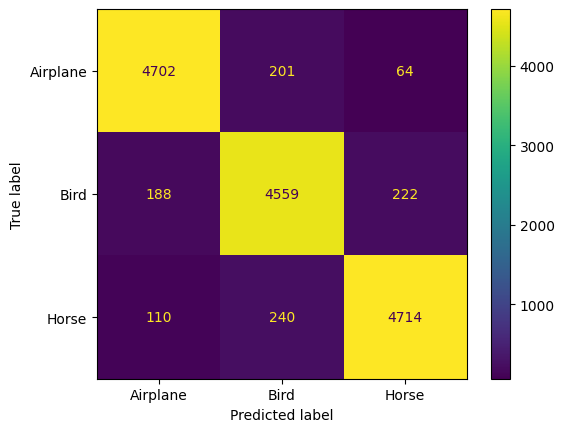

In [4]:
X_train_val = dataset.train["hog"]
y_train_val = dataset.train["labels"]
X_test = dataset.test["hog"]
y_test = dataset.test["labels"]



clf = Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel = 'rbf',C=1.0, gamma='scale'))]) #default parameters
#Description 
clf.fit(X_train_val, y_train_val)
pred_desc = clf.predict(X_train_val)

score_desc = accuracy_score(pred_desc, y_train_val)
cm = confusion_matrix(pred_desc, y_train_val)

print(classification_report(y_train_val, pred_desc))
print(f"Description Score: {score_desc}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.labels)
disp.plot()


              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1000
           1       0.76      0.77      0.76      1000
           2       0.86      0.84      0.85      1000

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000

Prediction Score: 0.8213333333333334


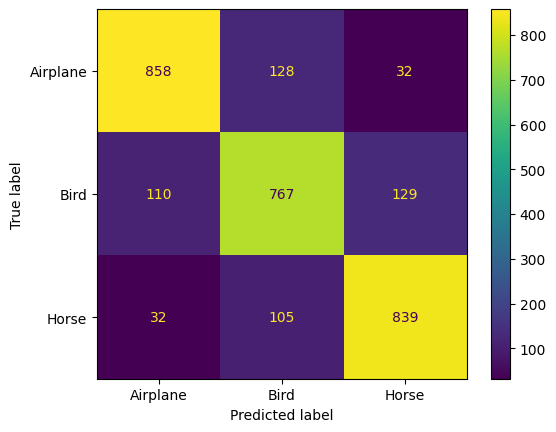

In [5]:
#Prediction
pred_test = clf.predict(X_test)

pred_score = accuracy_score(pred_test, y_test)
cm = confusion_matrix(pred_test, y_test)

print(classification_report(y_test, pred_test))
print(f"Prediction Score: {pred_score}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.labels)
disp.plot()

**Explore the classifier**. How many support vectors are there? What are support vectors?

In [9]:
svc = clf.named_steps["svc"]
all_support_vectors = svc.support_vectors_ #Each line = 1 "Support Vector" ; 1024 columns forming a 32x32 image 
vectors_per_class = svc.n_support_ #Number of "Support Vector" for each class
print(all_support_vectors.shape)
print(vectors_per_class)

(9025, 256)
[2756 3676 2593]


**Try to find the best "C" (error penalty) and "gamma" parameters** using cross-validation. What influence does "C" have on the number of support vectors?

In [8]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

param_grid = [
   
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10],
        "svc__gamma": [0.001, 0.01, 0.1]
    }
]

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_val, y_train_val)

print(grid.best_params_)
print(grid.best_score_)

{'svc__C': 10, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
0.8108


Test Score: 0.8233333333333334
Confusion Matrix:
[[848 106  29]
 [116 776 125]
 [ 36 118 846]]


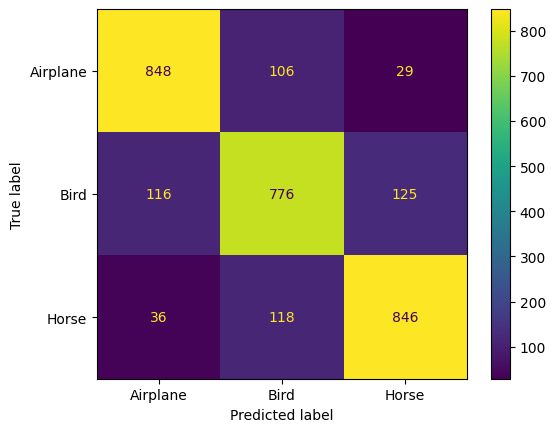

In [24]:
pred_test = grid.predict(X_test)

score_test = accuracy_score(pred_test, y_test)
cm = confusion_matrix(pred_test, y_test)
print(f"Test Score: {score_test}")
print(f"Confusion Matrix:\n{cm}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.labels)
disp.plot()

# Comparing algorithms

Using the best hyper-parameters that you found for each of the algorithms (kNN, Decision Trees, Random Forests, MLP, SVM):

* Re-train the models on the full training set.
* Compare their results on the test set.

In [19]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)


X_train = dataset.train["hog"]
y_train = dataset.train["labels"]
X_test = dataset.test["hog"]
y_test = dataset.test["labels"]

class_names = dataset.labels


#Best model (cf. other labs)

models = {
    "KNN": Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier(n_neighbors=7,p=1,weights="distance"))]),
    "Decision Tree": DecisionTreeClassifier(criterion="gini",max_depth=10,min_samples_leaf=1,random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=None,min_samples_leaf=1,random_state=0,n_jobs=-1),
    "MLP": Pipeline([("scaler", StandardScaler()),("mlp", MLPClassifier(hidden_layer_sizes=(100,),alpha=0.0001,max_iter=500,random_state=0))]),
    "SVC": Pipeline([("scaler", StandardScaler()),("svc", SVC(kernel="rbf",C=10,gamma=0.001))])
}


results = []
predictions = {}
confusion_matrices = {}

for name, model in models.items():
    print(f"\n---Training {name}---")
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    #pred
    predictions[name] = y_test_pred
     
    #metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test,y_test_pred,average="macro")
    recall = recall_score(y_test,y_test_pred,average="macro")
    f1 = f1_score(y_test,y_test_pred,average="macro")
    
    #overfitting gap
    gap = train_acc - test_acc
    
    cm = confusion_matrix(y_test, y_test_pred)
    confusion_matrices[name] = cm
    
    results.append({
        "Model": name,
        "Train accuracy": train_acc,
        "Test accuracy": test_acc,
        "Train-Test gap": gap,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })
    
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy : {test_acc:.4f}")
    print(f"Gap           : {gap:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test,y_test_pred,target_names=class_names))


#summary
results = sorted(
    results,
    key=lambda x: x["Test accuracy"],
    reverse=True
)

print("\n---Model comparison---\n")

print(
    f"{'Model':<15}"
    f"{'Train Acc':<12}"
    f"{'Test Acc':<12}"
    f"{'Gap':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1-score':<12}"
)

for r in results:
    print(
        f"{r['Model']:<15}"
        f"{r['Train accuracy']:<12.4f}"
        f"{r['Test accuracy']:<12.4f}"
        f"{r['Train-Test gap']:<12.4f}"
        f"{r['Precision']:<12.4f}"
        f"{r['Recall']:<12.4f}"
        f"{r['F1-score']:<12.4f}"
    )


---Training KNN---
Train accuracy: 1.0000
Test accuracy : 0.7920
Gap           : 0.2080

Classification report:
              precision    recall  f1-score   support

    Airplane       0.88      0.77      0.82      1000
        Bird       0.71      0.79      0.74      1000
       Horse       0.81      0.82      0.82      1000

    accuracy                           0.79      3000
   macro avg       0.80      0.79      0.79      3000
weighted avg       0.80      0.79      0.79      3000


---Training Decision Tree---
Train accuracy: 0.7992
Test accuracy : 0.6063
Gap           : 0.1929

Classification report:
              precision    recall  f1-score   support

    Airplane       0.69      0.61      0.65      1000
        Bird       0.54      0.63      0.58      1000
       Horse       0.61      0.58      0.60      1000

    accuracy                           0.61      3000
   macro avg       0.61      0.61      0.61      3000
weighted avg       0.61      0.61      0.61      3000


-

Tableau propre avec valeurs arrondies :

In [20]:
print("\nBest model based on test accuracy:")
print(results[0]["Model"])


Best model based on test accuracy:
SVC


Barplot des performance test

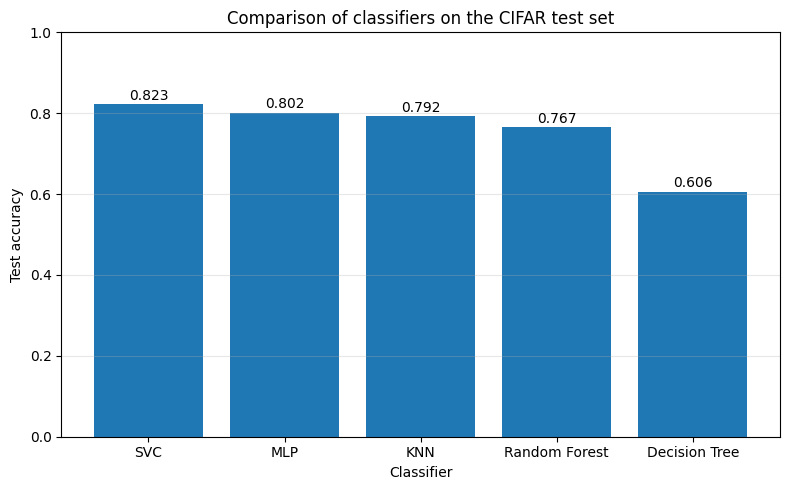

In [21]:
import matplotlib.pyplot as plt

# results est déjà trié par Test accuracy
model_names = [r["Model"] for r in results]
test_acc = [r["Test accuracy"] for r in results]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, test_acc)

plt.title("Comparison of classifiers on the CIFAR test set")
plt.ylabel("Test accuracy")
plt.xlabel("Classifier")
plt.ylim(0,1)

# Afficher les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

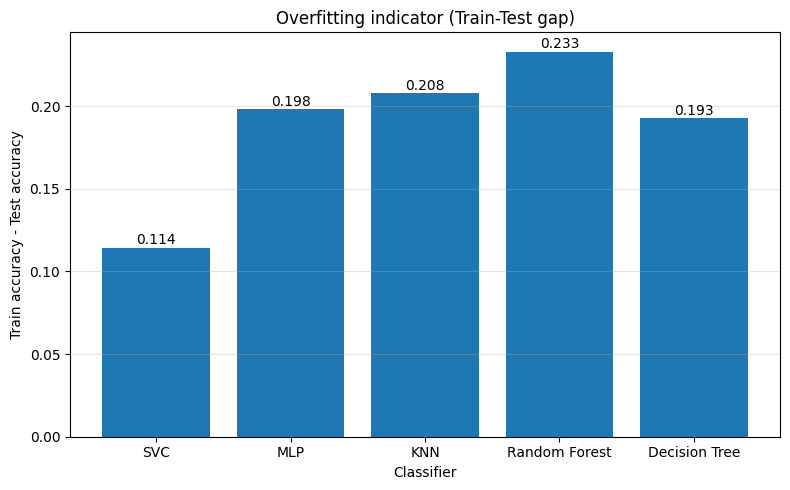

In [22]:
gaps = [r["Train-Test gap"] for r in results]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, gaps)

plt.title("Overfitting indicator (Train-Test gap)")
plt.ylabel("Train accuracy - Test accuracy")
plt.xlabel("Classifier")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Matrice du meilleur modèle

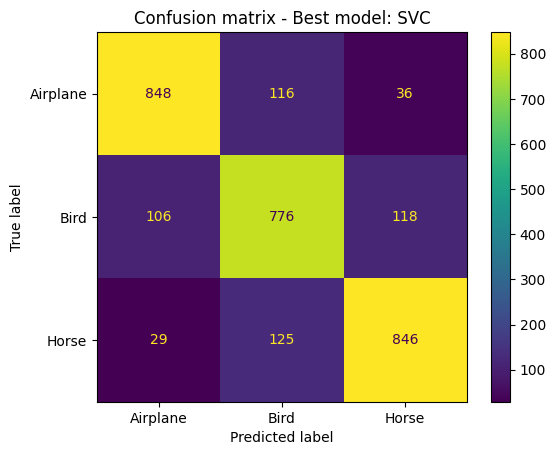

In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_cm = confusion_matrices[best_model_name]

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=class_names
)

disp.plot()
plt.title(f"Confusion matrix - Best model: {best_model_name}")
plt.show()